In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(f"/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/suppressing_CTCFs/results_repeated/only_successful_seqs_with_results.tsv", sep="\t")

In [3]:
df_control = pd.read_csv(f"/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/suppressing_CTCFs/results_control_repeated/all_successful_control.tsv", sep="\t")

In [4]:
# 1. Load the data
df_sineb2 = pd.read_csv('sine_b2_insertion_results.tsv', sep='\t')

/tmp/SLURM_2703723/ipykernel_1409591/1502238133.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Category', y='URQ', data=plot_df, palette='Set2')


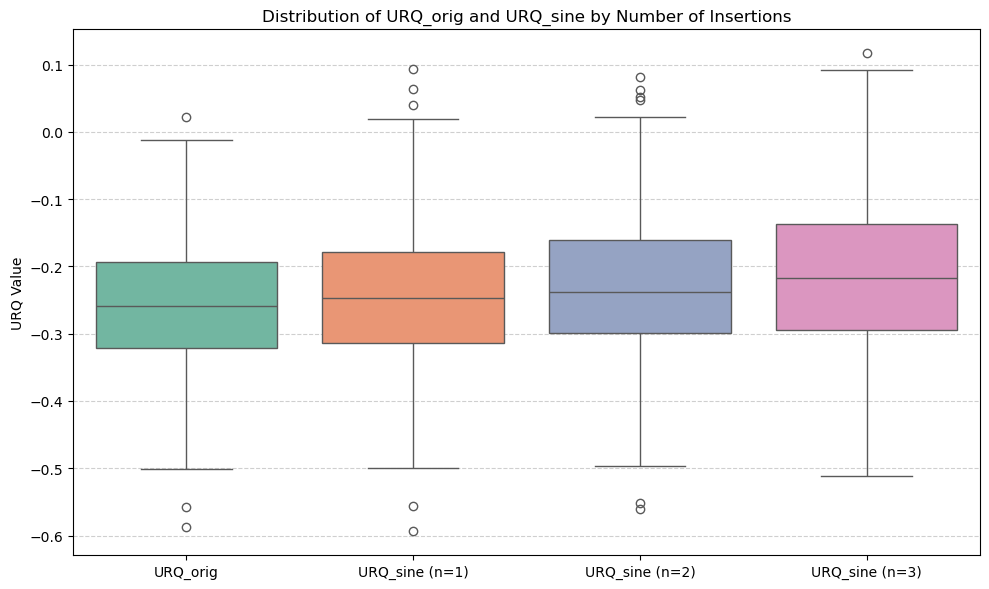

In [5]:
# 1. Prepare the data for plotting
# Create a DataFrame for URQ_orig
df_orig = pd.DataFrame({
    'URQ': df_sineb2[df_sineb2["n_insertions"] == 1]['URQ_orig'],
    'Category': 'URQ_orig'
})

# Create DataFrames for URQ_sine for each n_insertions (1, 2, 3)
df_sine_list = []
for n in [1, 2, 3]:
    subset = df_sineb2[df_sineb2['n_insertions'] == n].copy()
    if not subset.empty:
        temp_df = pd.DataFrame({
            'URQ': subset['URQ_sine'],
            'Category': f'URQ_sine (n={n})'
        })
        df_sine_list.append(temp_df)

# 2. Combine all parts into one plotting DataFrame
plot_df = pd.concat([df_orig] + df_sine_list, ignore_index=True)

# 3. Create the boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='Category', y='URQ', data=plot_df, palette='Set2')

# Optional: Add swarmplot to see individual points (good for small datasets)
# sns.swarmplot(x='Category', y='URQ', data=plot_df, color=".25")

plt.title('Distribution of URQ_orig and URQ_sine by Number of Insertions')
plt.ylabel('URQ Value')
plt.xlabel('')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
# plt.savefig('urq_distribution_boxplot.png')
plt.show()

In [6]:
df["Bbox_URQ_diff"] = df["URQ_no_bbox"] - df["URQ_init"]

/tmp/SLURM_2703723/ipykernel_1409591/1756341728.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


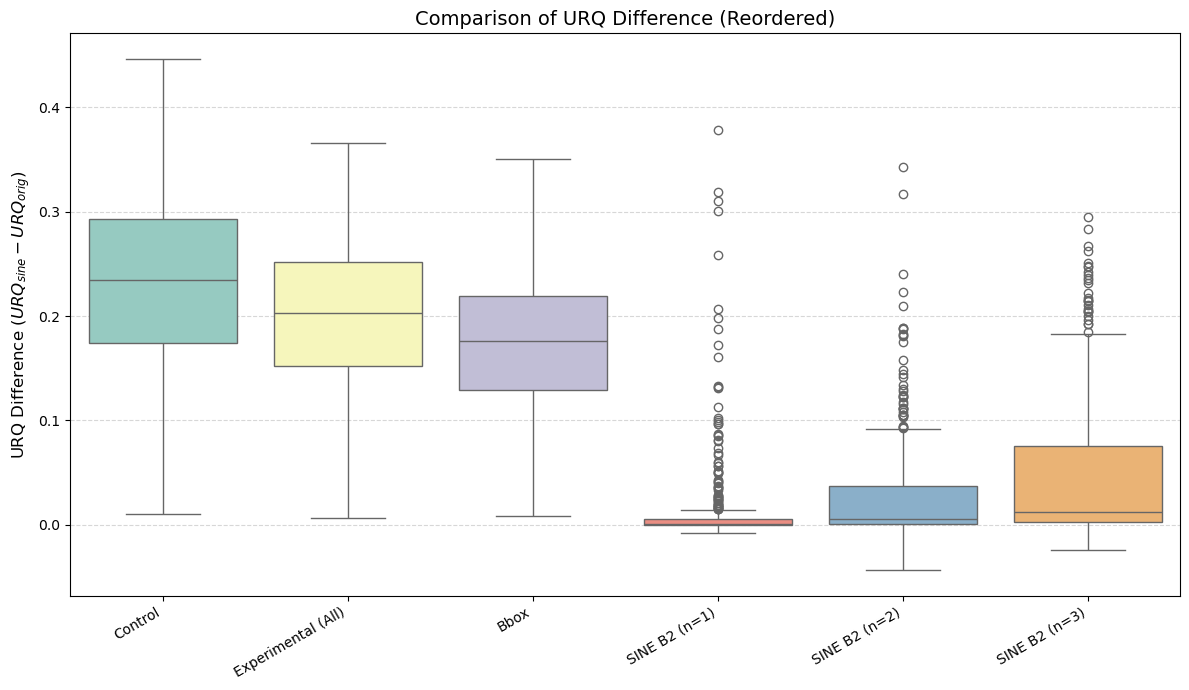

In [7]:
# 1. Prepare the data segments
plot_data = []

# Control
plot_data.append(pd.DataFrame({'URQ_diff': df_control['URQ_diff'], 'Category': 'Control'}))

# Experimental (All)
plot_data.append(pd.DataFrame({'URQ_diff': df['URQ_diff'], 'Category': 'Experimental (All)'}))

# Bbox
plot_data.append(pd.DataFrame({'URQ_diff': df['Bbox_URQ_diff'], 'Category': 'Bbox'}))

# SINE B2 insertions (1, 2, 3)
for n in [1, 2, 3]:
    subset = df_sineb2[df_sineb2['n_insertions'] == n]
    if not subset.empty:
        plot_data.append(pd.DataFrame({
            'URQ_diff': subset['URQ_diff'], 
            'Category': f'SINE B2 (n={n})'
        }))

# 2. Combine into one DataFrame
combined_plot_df = pd.concat(plot_data, ignore_index=True)

# 3. Define the explicit order for the X-axis
category_order = [
    'Control', 
    'Experimental (All)', 
    'Bbox', 
    'SINE B2 (n=1)', 
    'SINE B2 (n=2)', 
    'SINE B2 (n=3)'
]

# 4. Generate the plot
plt.figure(figsize=(12, 7))
sns.boxplot(
    x='Category', 
    y='URQ_diff', 
    data=combined_plot_df, 
    order=category_order,  # This enforces your requested order
    palette='Set3'
)

# Formatting
plt.title('Comparison of URQ Difference (Reordered)', fontsize=14)
plt.ylabel('URQ Difference ($URQ_{sine} - URQ_{orig}$)', fontsize=12)
plt.xlabel('')
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
# plt.savefig("URQ_comparison.svg", format="svg")
plt.show()

/tmp/SLURM_2703723/ipykernel_1409591/1347874182.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(data_to_plot, labels=labels, patch_artist=True,


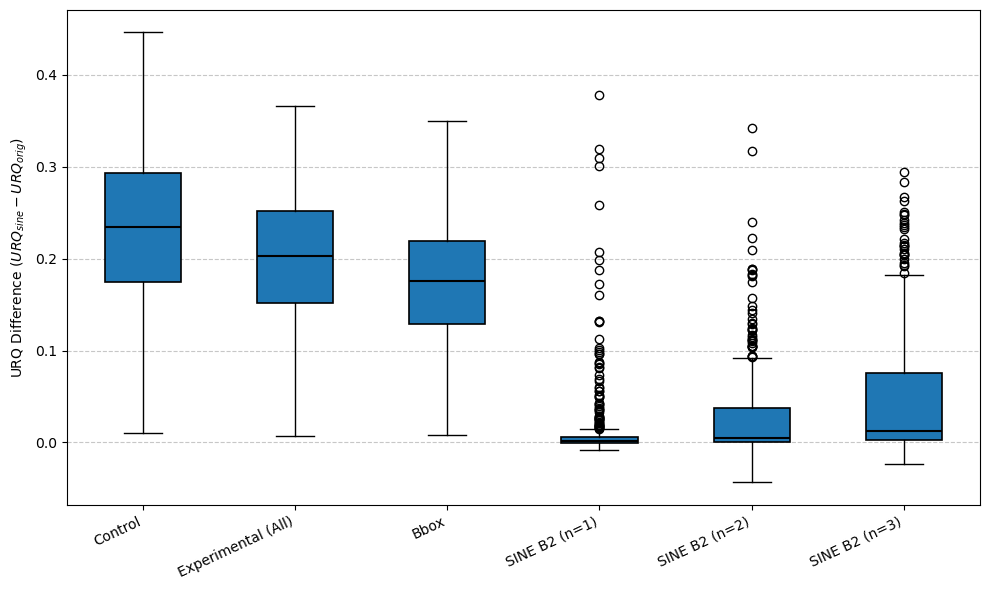

In [8]:
# 1. Prepare the data list and labels in the requested order
data_to_plot = [
    df_control["URQ_diff"].dropna(),
    df["URQ_diff"].dropna(),
    df["Bbox_URQ_diff"].dropna(),
    df_sineb2[df_sineb2['n_insertions'] == 1]["URQ_diff"].dropna(),
    df_sineb2[df_sineb2['n_insertions'] == 2]["URQ_diff"].dropna(),
    df_sineb2[df_sineb2['n_insertions'] == 3]["URQ_diff"].dropna()
]

labels = [
    "Control",
    "Experimental (All)",
    "Bbox",
    "SINE B2 (n=1)",
    "SINE B2 (n=2)",
    "SINE B2 (n=3)"
]

# 2. Plotting using the user's style
plt.figure(figsize=(10, 6))

# patch_artist=True is essential to allow color filling
bp = plt.boxplot(data_to_plot, labels=labels, patch_artist=True, 
                 medianprops=dict(color="black", linewidth=1.5),
                 boxprops=dict(linewidth=1.2))

# # 3. Set all boxes to a uniform blue color
# for patch in bp['boxes']:
#     # You can use 'blue', 'skyblue', or '#3498db' for different shades
#     patch.set_facecolor('#3498db') 

# Formatting
plt.ylabel("URQ Difference ($URQ_{sine} - URQ_{orig}$)")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=25, ha='right')

plt.tight_layout()
plt.show()
# plt.savefig("URQ_comparison.svg", format="svg")

In [14]:
df_sineb2 = df_sineb2.rename(columns={'URQ_orig': 'URQ_init'})

/tmp/SLURM_2703723/ipykernel_1409591/4070251658.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(data_to_plot, labels=labels, patch_artist=True,


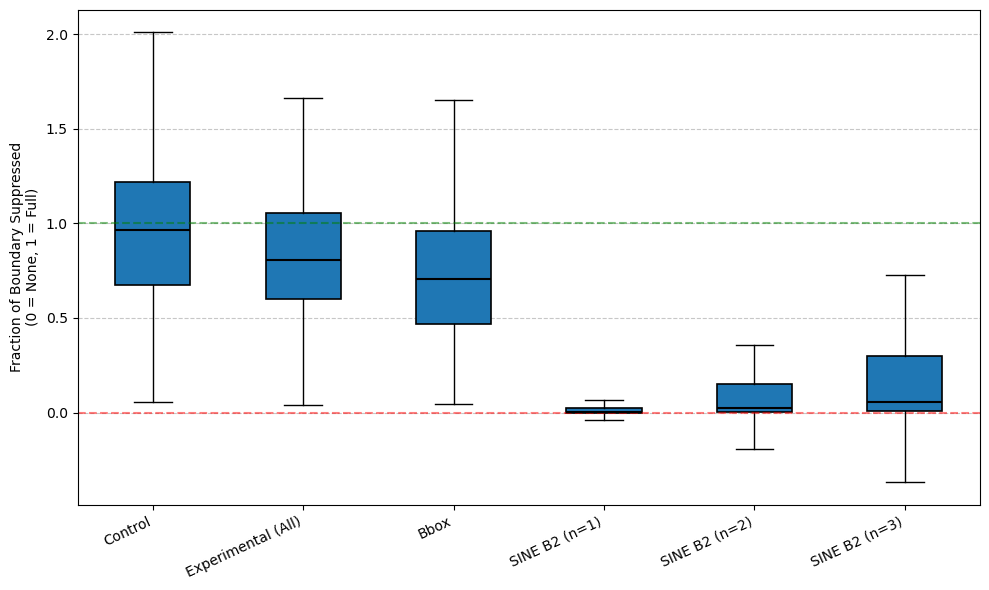

In [23]:
# Define a helper function to scale the data
def get_scaled_diff(dataframe, col_name="URQ_diff"):
    # Suppression fraction = (URQ_sine - URQ_orig) / (0 - URQ_orig)
    # Note: URQ_orig is usually negative, so -URQ_orig is positive.
    return dataframe[col_name] / (-dataframe["URQ_init"])

# 1. Prepare the scaled data list
data_to_plot = [
    get_scaled_diff(df_control).dropna(),
    get_scaled_diff(df).dropna(),
    # For Bbox, ensure you use the correct denominator if URQ_orig is different
    df["Bbox_URQ_diff"].dropna() / (-df["URQ_init"]), 
    get_scaled_diff(df_sineb2[df_sineb2['n_insertions'] == 1]).dropna(),
    get_scaled_diff(df_sineb2[df_sineb2['n_insertions'] == 2]).dropna(),
    get_scaled_diff(df_sineb2[df_sineb2['n_insertions'] == 3]).dropna()
]

labels = [
    "Control",
    "Experimental (All)",
    "Bbox",
    "SINE B2 (n=1)",
    "SINE B2 (n=2)",
    "SINE B2 (n=3)"
]

# 2. Plotting
plt.figure(figsize=(10, 6))
bp = plt.boxplot(data_to_plot, labels=labels, patch_artist=True, 
                 showfliers=False,
                 medianprops=dict(color="black", linewidth=1.5),
                 boxprops=dict(linewidth=1.2))

# # 3. Style the boxes
# for patch in bp['boxes']:
#     patch.set_facecolor('#3498db') 

# Formatting
plt.ylabel("Fraction of Boundary Suppressed\n(0 = None, 1 = Full)")
plt.axhline(y=1, color='green', linestyle='--', alpha=0.5, label='Full Suppression')
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=25, ha='right')

plt.tight_layout()
# plt.savefig("URQ_suppression_fraction.svg", format="svg")
plt.show()